In [1]:
# instalation de bibliothèques
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score,f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir())

# Any results you write to the current directory are saved as output.

['.ipynb_checkpoints', 'code de classification.ipynb', 'german_credit_data.csv']


In [2]:
#Apple dataset
import os
import glob
import pandas as pd
import numpy as np

allFiles = glob.glob("german_credit_data.csv")  # Spécifier le fichier exact

len(allFiles)
print(allFiles)

['german_credit_data.csv']


Dataset chargé : 1000 lignes, 9 colonnes

Colonnes disponibles : ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Aperçu :


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car



Statistiques :


,Age,Job,Credit amount,Duration
count,1000.00,1000.00,1000.00,1000.00
mean,35.55,1.90,3271.26,20.90
std,11.38,0.65,2822.74,12.06
min,19.00,0.00,250.00,4.00
25%,27.00,2.00,1365.50,12.00
50%,33.00,2.00,2319.50,18.00
75%,42.00,2.00,3972.25,24.00
max,75.00,3.00,18424.00,72.00



Distribution du risque :
Risk
good    650
bad     350
Name: count, dtype: int64

Colonne numérique 1 : Age
Colonne numérique 2 : Credit amount
Colonne catégorielle : Housing


C:\Users\Media House\AppData\Local\Temp\ipykernel_7560\3680239949.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


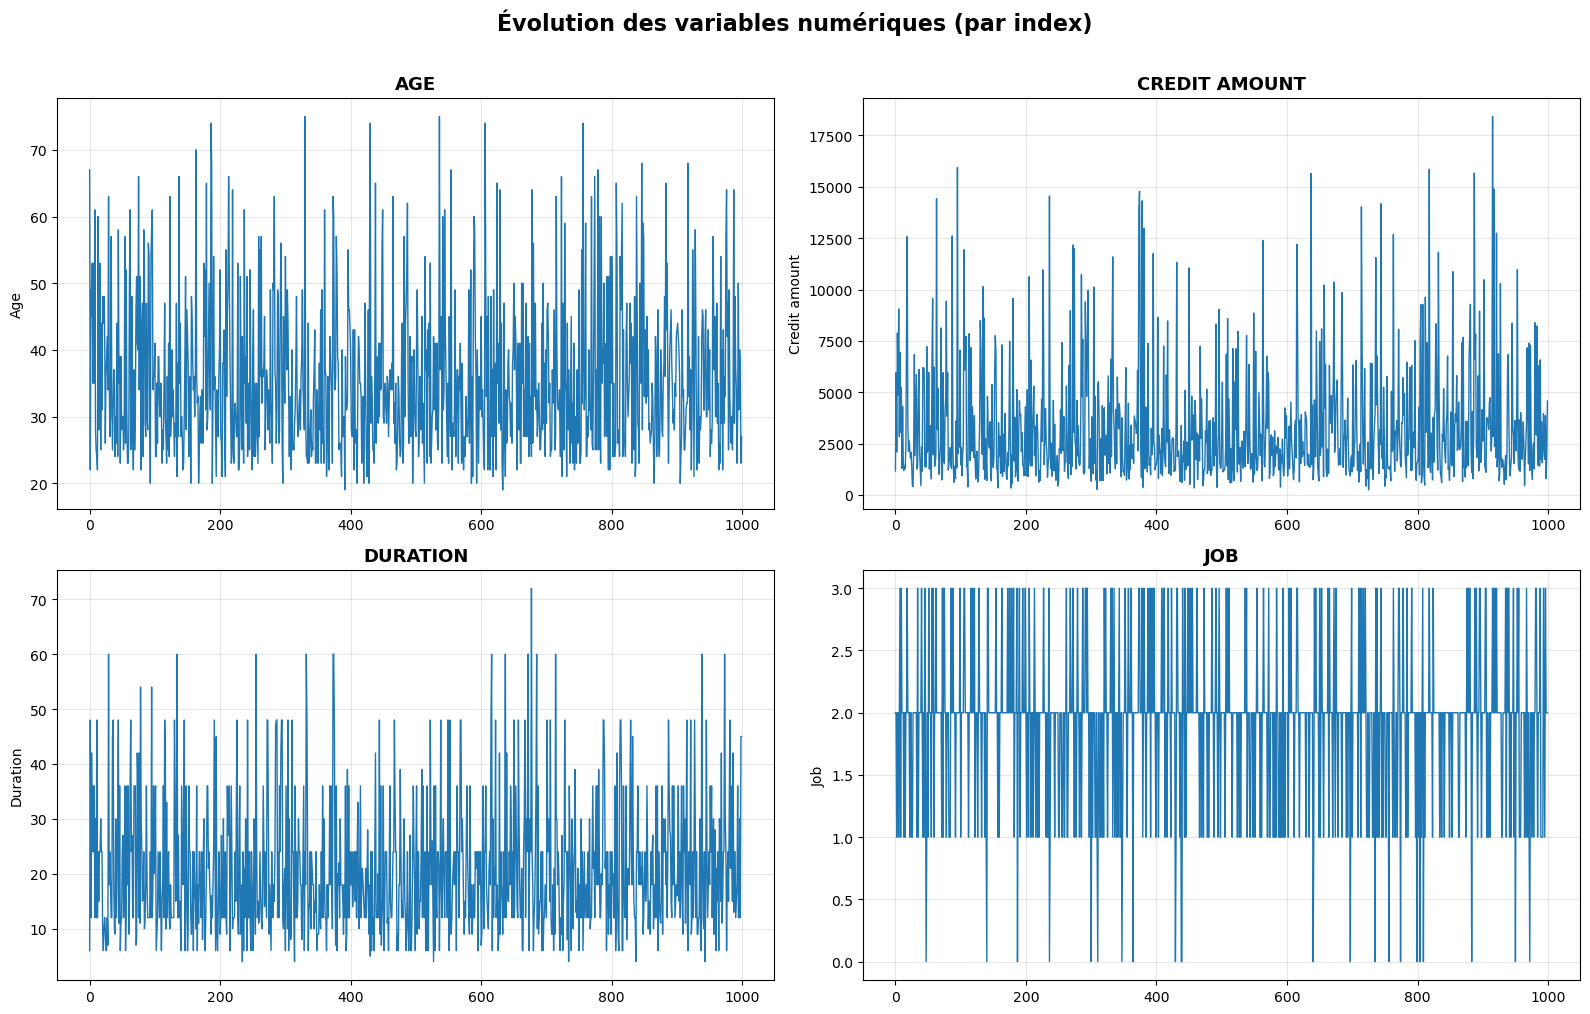

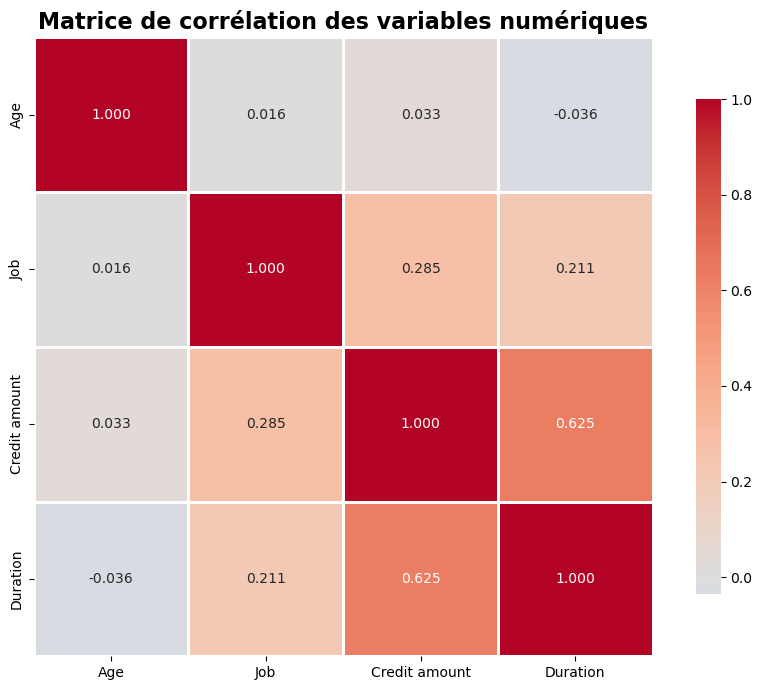

C:\Users\Media House\AppData\Local\Temp\ipykernel_7560\3680239949.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
C:\Users\Media House\AppData\Local\Temp\ipykernel_7560\3680239949.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
C:\Users\Media House\AppData\Local\Temp\ipykernel_7560\3680239949.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
C:\Users\Media House\AppData\Local\Temp\ipykernel_7560\368023994

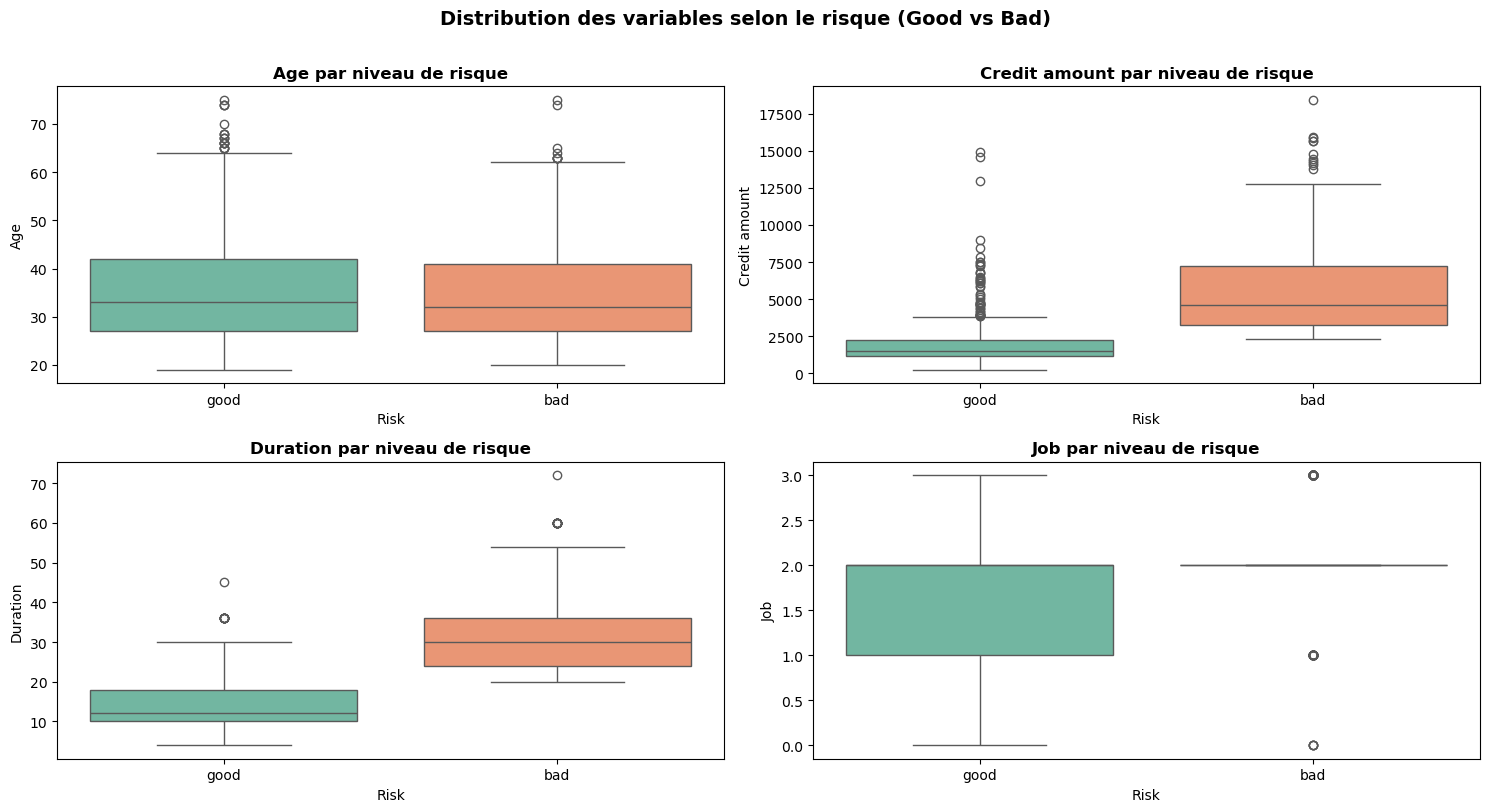

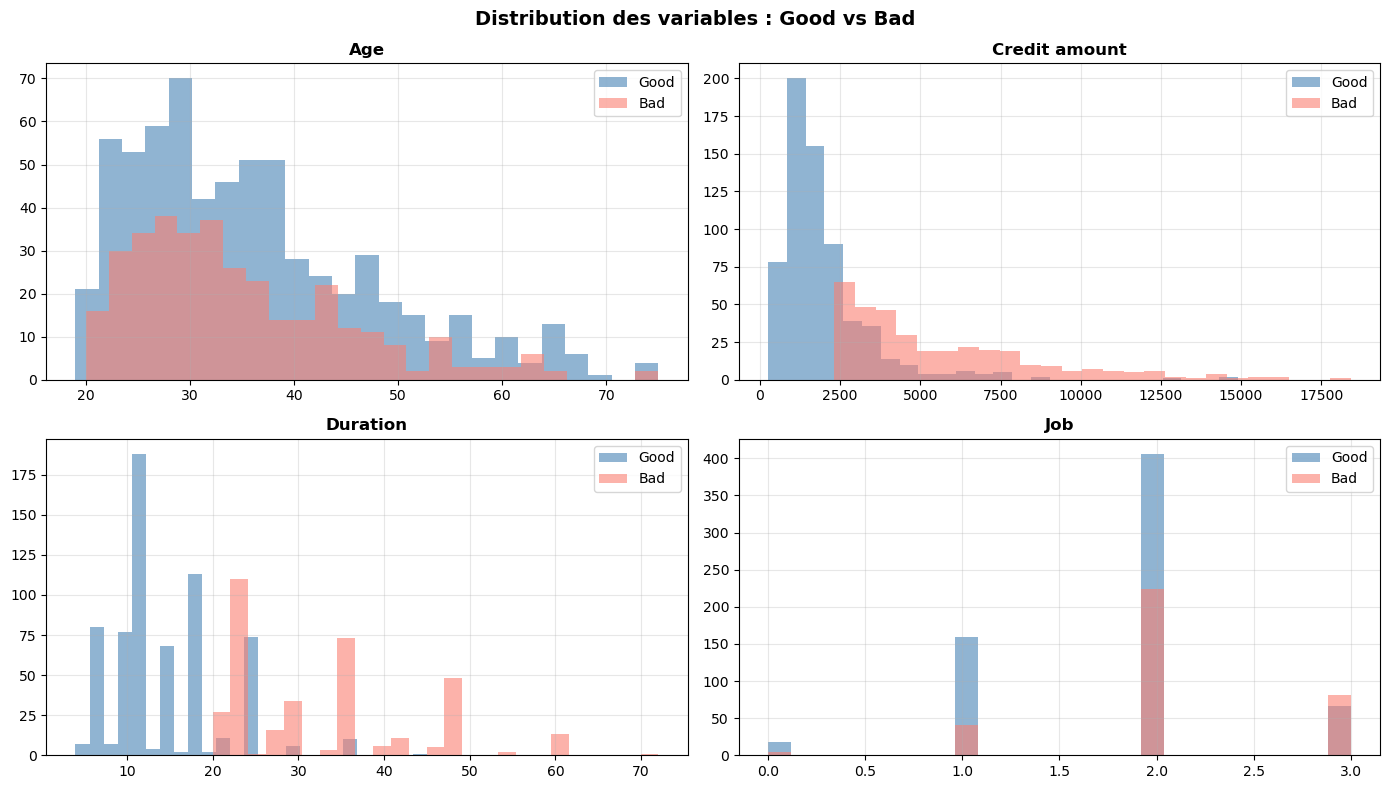

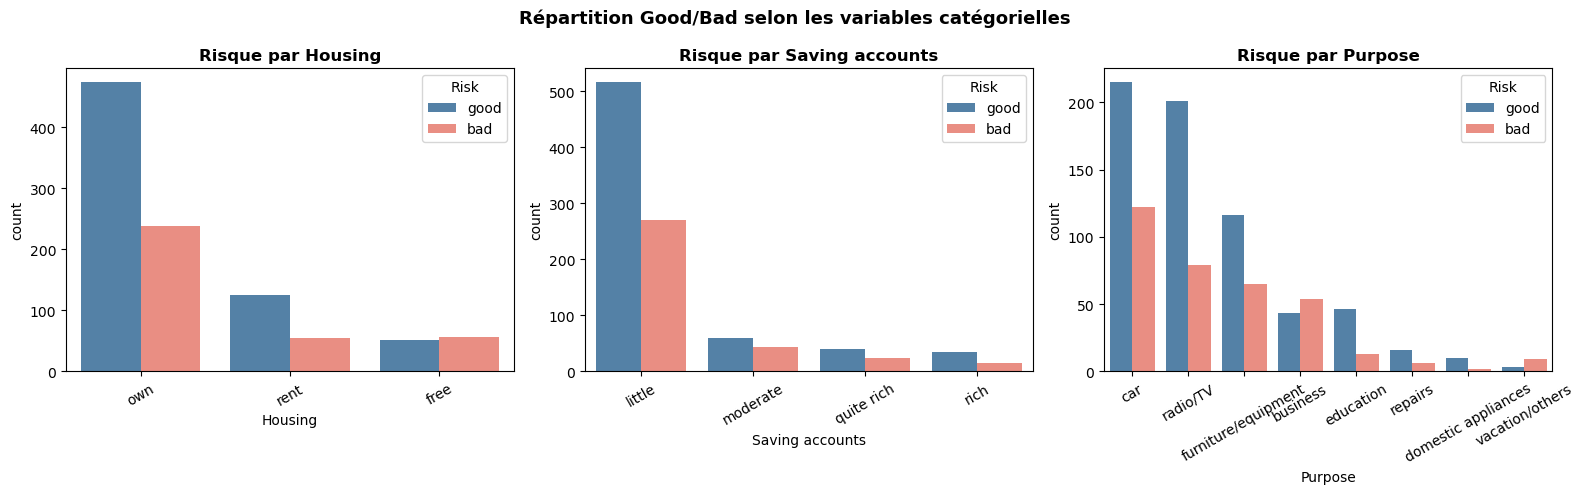

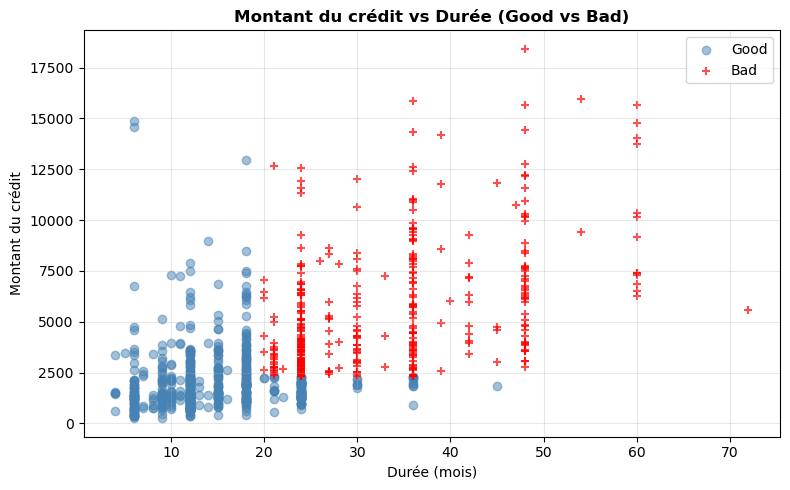

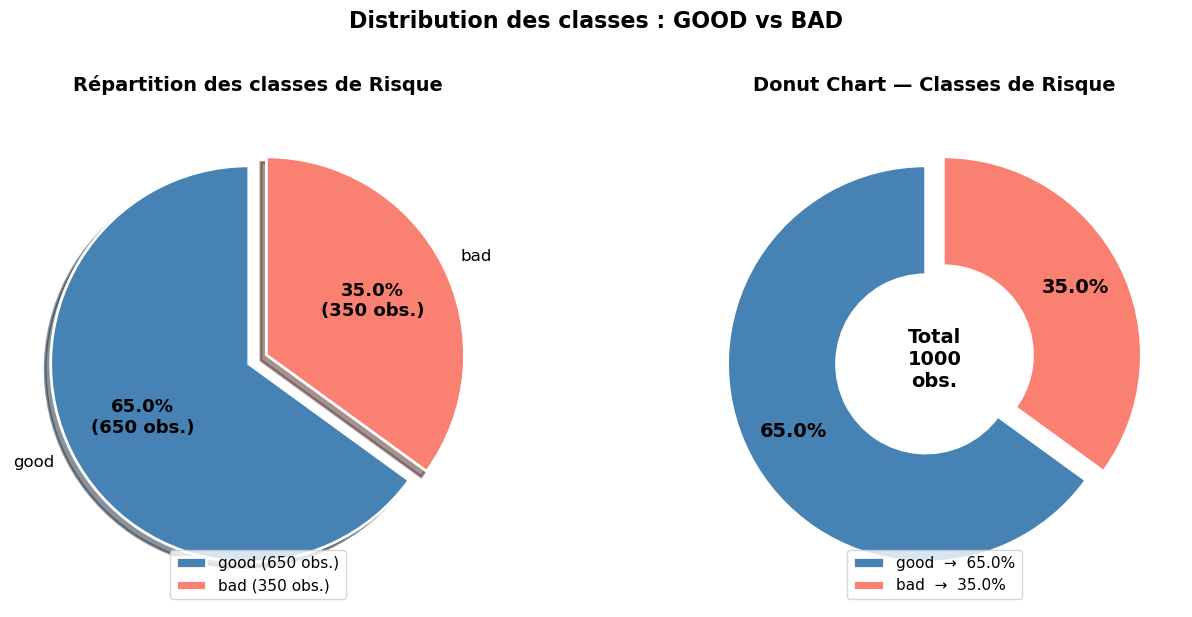

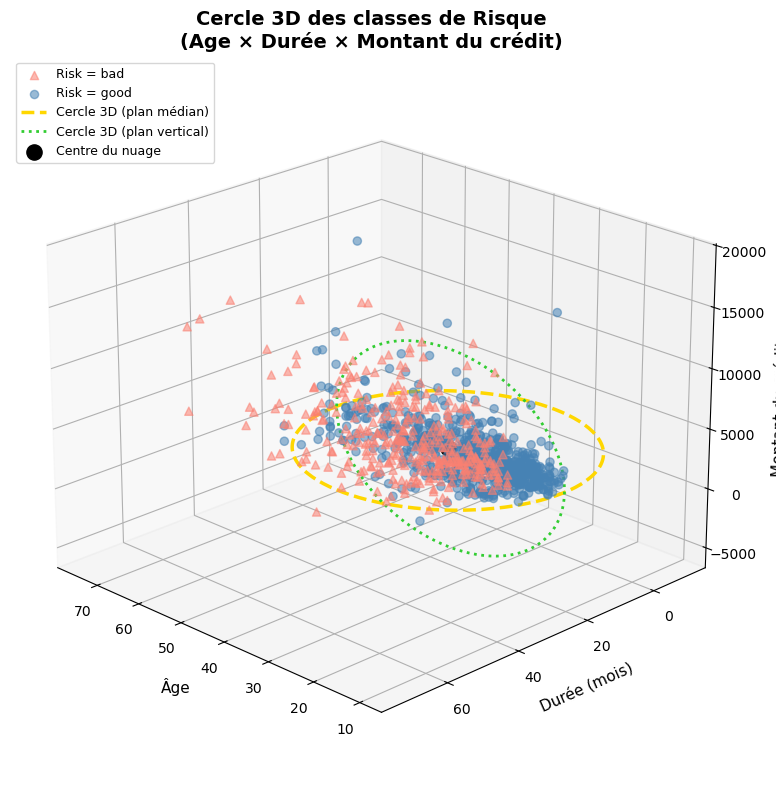


DataFrame final 'data' créé avec succès !
Colonnes : ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']
Shape    : (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,bad
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,little,little,9055,36,education,bad
6,53,male,2,own,quite rich,little,2835,24,furniture/equipment,bad
7,35,male,3,rent,little,moderate,6948,36,car,bad
8,61,male,1,own,rich,little,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad



Fichier sauvegardé : german_credit_FINAL_ML_READY.csv
Prêt pour scikit-learn, TensorFlow, etc.


In [3]:
#carecteristeque dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# -------------------------------
# 1. CHARGEMENT DU FICHIER
# -------------------------------
df = pd.read_csv("german_credit_data.csv", index_col=0)
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\nColonnes disponibles :", df.columns.tolist())
print("\nAperçu :")
display(df.head(10))
print("\nStatistiques :")
display(df.describe().round(2))

# -------------------------------
# 2. CRÉATION DE LA VARIABLE CIBLE "Risk"
#    bad = Credit amount ET Duration > médiane
# -------------------------------
df["Risk"] = "good"
mask = (df["Credit amount"] > df["Credit amount"].median()) & \
       (df["Duration"]      > df["Duration"].median())
df.loc[mask, "Risk"] = "bad"

print(f"\nDistribution du risque :\n{df['Risk'].value_counts()}")

# Imputation des valeurs manquantes par le mode
for col in ["Saving accounts", "Checking account"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------------
# 3. IDENTIFICATION DES COLONNES CLÉS
# -------------------------------
num_col1 = "Age"
num_col2 = "Credit amount"
cat_col  = "Housing"
print(f"\nColonne numérique 1 : {num_col1}")
print(f"Colonne numérique 2 : {num_col2}")
print(f"Colonne catégorielle : {cat_col}")

# -------------------------------
# 4. VISUALISATION TEMPORELLE (évolution par index)
# -------------------------------
plt.figure(figsize=(16, 10))
cols_to_plot = ["Age", "Credit amount", "Duration", "Job"]
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    plt.plot(df[col].values, color='tab:blue', linewidth=1.0)
    plt.title(col.upper(), fontsize=13, fontweight='bold')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)

plt.suptitle("Évolution des variables numériques (par index)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("plot_temporal.png", dpi=100)
plt.show()

# -------------------------------
# 5. MATRICE DE CORRÉLATION
# -------------------------------
plt.figure(figsize=(9, 7))
corr_cols = ["Age", "Job", "Credit amount", "Duration"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".3f",
            square=True, linewidths=0.8, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation des variables numériques",
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_corr.png", dpi=100)
plt.show()

# -------------------------------
# 6. BOXPLOTS PAR RISQUE
# -------------------------------
plt.figure(figsize=(15, 8))
boxplot_cols = ["Age", "Credit amount", "Duration", "Job"]
for i, col in enumerate(boxplot_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
    plt.title(f"{col} par niveau de risque", fontweight='bold')
plt.suptitle("Distribution des variables selon le risque (Good vs Bad)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("plot_boxplots.png", dpi=100)
plt.show()

# -------------------------------
# 7. DISTRIBUTIONS COMPARÉES (Good vs Bad)
# -------------------------------
good = df[df["Risk"] == "good"]
bad  = df[df["Risk"] == "bad"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ["Age", "Credit amount", "Duration", "Job"]):
    ax.hist(good[col], bins=25, alpha=0.6, label="Good", color="steelblue")
    ax.hist(bad[col],  bins=25, alpha=0.6, label="Bad",  color="salmon")
    ax.set_title(col, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Distribution des variables : Good vs Bad",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_distributions.png", dpi=100)
plt.show()

# -------------------------------
# 8. VARIABLES CATÉGORIELLES
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Housing", "Saving accounts", "Purpose"]):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue="Risk", data=df, ax=ax,
                  order=order, palette={"good": "steelblue", "bad": "salmon"})
    ax.set_title(f"Risque par {col}", fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle("Répartition Good/Bad selon les variables catégorielles",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_categoriel.png", dpi=100)
plt.show()

# -------------------------------
# 9. SCATTER : Credit amount vs Duration
# -------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(good["Duration"], good["Credit amount"],
            marker="o", alpha=0.5, label="Good", color="steelblue")
plt.scatter(bad["Duration"],  bad["Credit amount"],
            marker="+", alpha=0.7, label="Bad",  color="red")
plt.xlabel("Durée (mois)"); plt.ylabel("Montant du crédit")
plt.title("Montant du crédit vs Durée (Good vs Bad)", fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_scatter.png", dpi=100)
plt.show()

# -------------------------------
# 10. CAMEMBERT (PIE CHART) DES % DE CLASSES DE RISQUE
# -------------------------------
risk_counts = df["Risk"].value_counts()
labels      = risk_counts.index.tolist()
sizes       = risk_counts.values.tolist()
colors_pie  = ["steelblue", "salmon"]
explode     = (0.05, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Camembert simple ---
wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels    = labels,
    colors    = colors_pie,
    explode   = explode,
    autopct   = lambda p: f"{p:.1f}%\n({int(round(p*sum(sizes)/100))} obs.)",
    startangle= 90,
    shadow    = True,
    wedgeprops= dict(linewidth=2, edgecolor='white'),
    textprops = dict(fontsize=12)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title("Répartition des classes de Risque",
                  fontsize=14, fontweight='bold', pad=15)
axes[0].legend(wedges, [f"{l} ({s} obs.)" for l, s in zip(labels, sizes)],
               loc="lower center", fontsize=11)

# --- Donut chart (anneau) avec % au centre ---
wedges2, texts2, autotexts2 = axes[1].pie(
    sizes,
    labels      = None,
    colors      = colors_pie,
    explode     = explode,
    autopct     = lambda p: f"{p:.1f}%",
    startangle  = 90,
    shadow      = False,
    pctdistance = 0.75,
    wedgeprops  = dict(width=0.55, linewidth=2, edgecolor='white'),
    textprops   = dict(fontsize=13, fontweight='bold')
)
for at in autotexts2:
    at.set_fontsize(14)
    at.set_fontweight('bold')

# Texte central du donut
axes[1].text(0, 0, f"Total\n{sum(sizes)}\nobs.",
             ha='center', va='center', fontsize=14, fontweight='bold', color='black')
axes[1].set_title("Donut Chart — Classes de Risque",
                  fontsize=14, fontweight='bold', pad=15)
axes[1].legend(wedges2, [f"{l}  →  {s/sum(sizes)*100:.1f}%" for l, s in zip(labels, sizes)],
               loc="lower center", fontsize=11)

plt.suptitle("Distribution des classes : GOOD vs BAD",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_pie_risque.png", dpi=120)
plt.show()

# -------------------------------
# 11. CERCLE 3D DES CLASSES DE RISQUE
# -------------------------------
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

colors  = {"good": "steelblue", "bad": "salmon"}
markers = {"good": "o",         "bad": "^"}

for risk_class, grp in df.groupby("Risk"):
    ax.scatter(
        grp["Age"], grp["Duration"], grp["Credit amount"],
        c=colors[risk_class], marker=markers[risk_class],
        alpha=0.55, s=35, label=f"Risk = {risk_class}"
    )

# Cercles 3D autour du nuage
theta = np.linspace(0, 2 * np.pi, 200)
cx = df["Age"].mean();           cy = df["Duration"].mean()
cz = df["Credit amount"].mean()
rx = (df["Age"].max()           - df["Age"].min())           / 2.2
ry = (df["Duration"].max()      - df["Duration"].min())      / 2.2
rz = (df["Credit amount"].max() - df["Credit amount"].min()) / 2.2

# Cercle horizontal (plan Age / Duration)
ax.plot(cx + rx * np.cos(theta), cy + ry * np.sin(theta),
        np.full_like(theta, cz),
        color='gold', linewidth=2.5, linestyle='--', label="Cercle 3D (plan médian)")

# Cercle vertical (plan Age / Credit amount)
ax.plot(cx + rx * np.cos(theta), np.full_like(theta, cy),
        cz + rz * np.sin(theta),
        color='limegreen', linewidth=2.0, linestyle=':', label="Cercle 3D (plan vertical)")

# Centre du nuage
ax.scatter([cx], [cy], [cz], color='black', s=120, zorder=5, label="Centre du nuage")

ax.set_xlabel("Âge",               fontsize=11, labelpad=8)
ax.set_ylabel("Durée (mois)",      fontsize=11, labelpad=8)
ax.set_zlabel("Montant du crédit", fontsize=11, labelpad=8)
ax.set_title("Cercle 3D des classes de Risque\n(Age × Durée × Montant du crédit)",
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.view_init(elev=22, azim=135)
plt.tight_layout()
plt.savefig("plot_cercle_3d_risque.png", dpi=120)
plt.show()

# -------------------------------
# 12. CRÉATION DU DATAFRAME FINAL POUR LE ML
# -------------------------------
cols_to_drop = ["id"] if "id" in df.columns else []
data = df.drop(columns=cols_to_drop).copy()
data = data.reset_index(drop=True)

print("\nDataFrame final 'data' créé avec succès !")
print("Colonnes :", data.columns.tolist())
print("Shape    :", data.shape)
display(data.head(10))

# -------------------------------
# 13. SAUVEGARDE DU FICHIER FINAL
# -------------------------------
data.to_csv("german_credit_FINAL_ML_READY.csv", index=False, sep=";")
print("\nFichier sauvegardé : german_credit_FINAL_ML_READY.csv")
print("Prêt pour scikit-learn, TensorFlow, etc.")

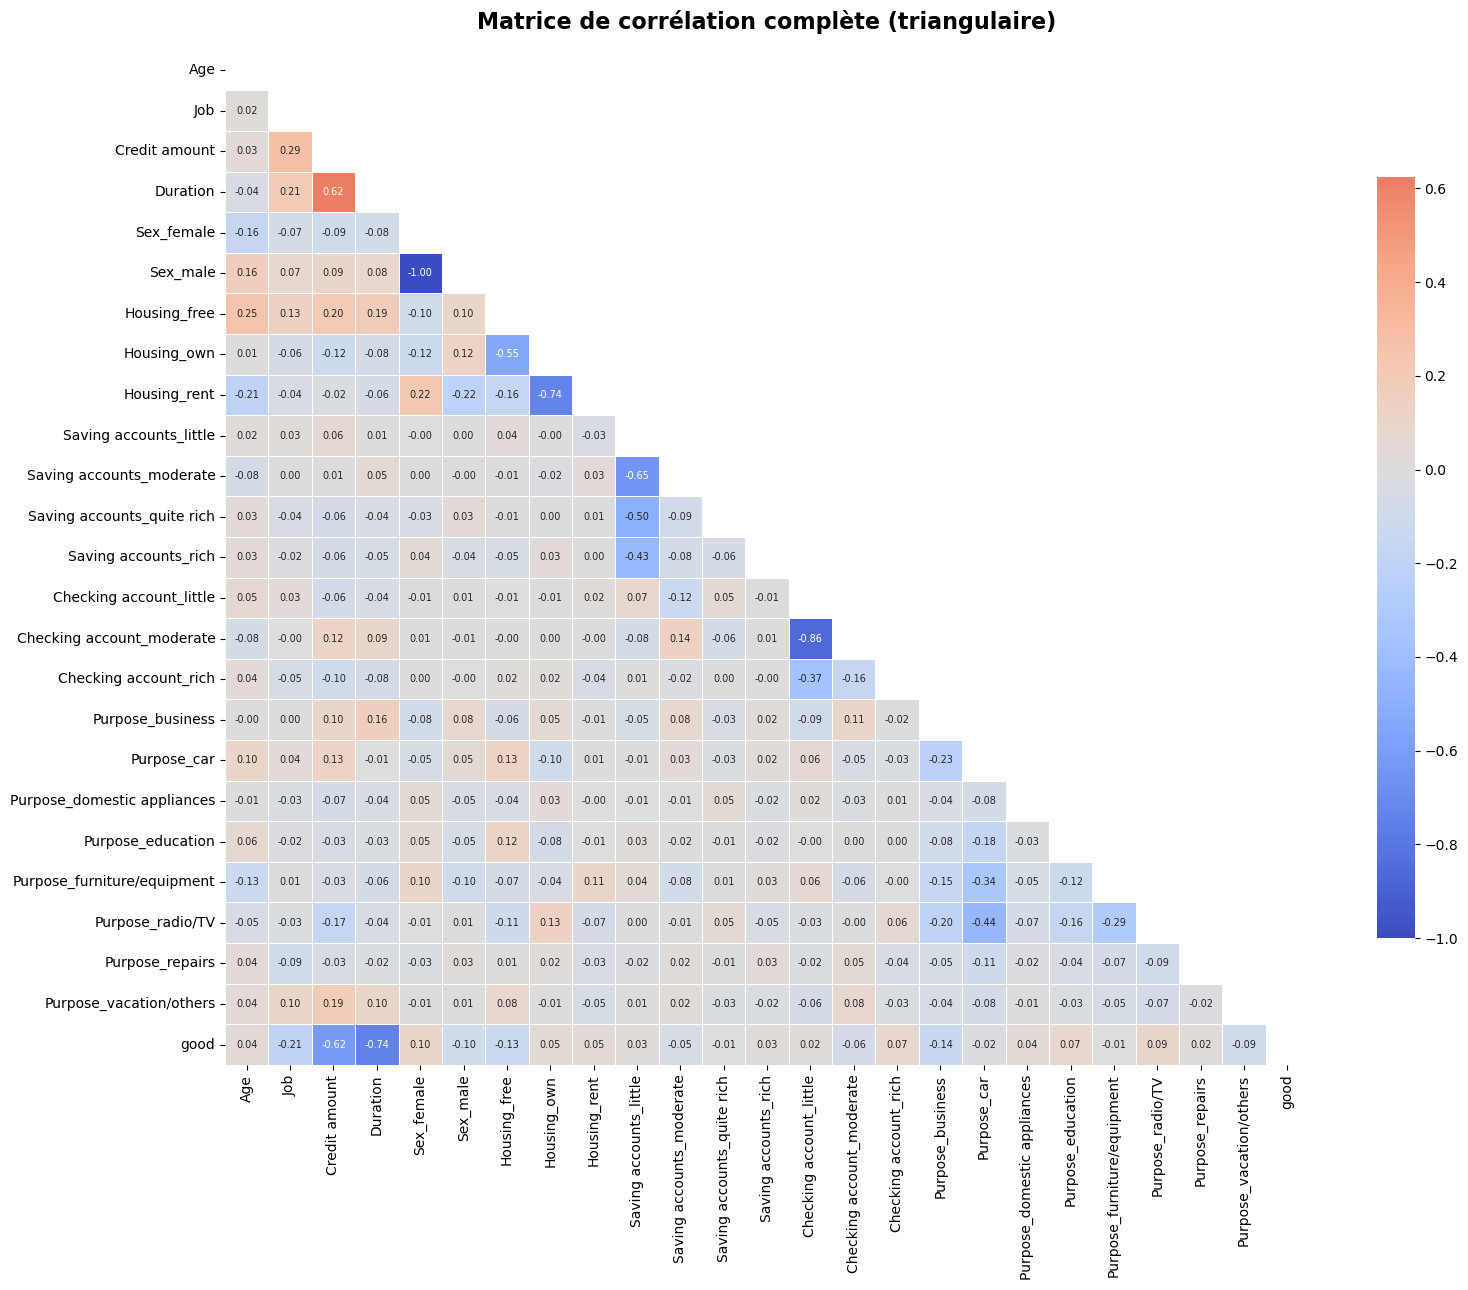

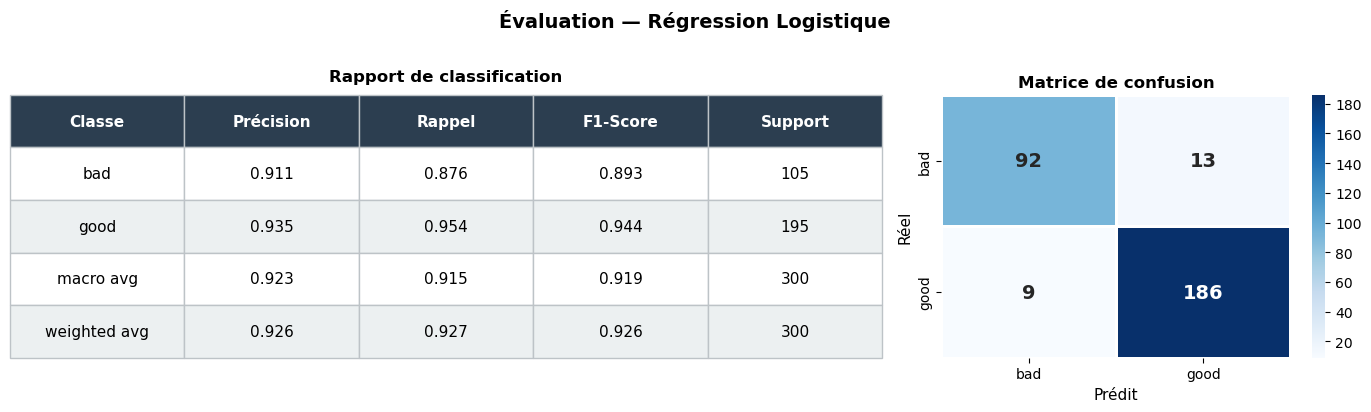

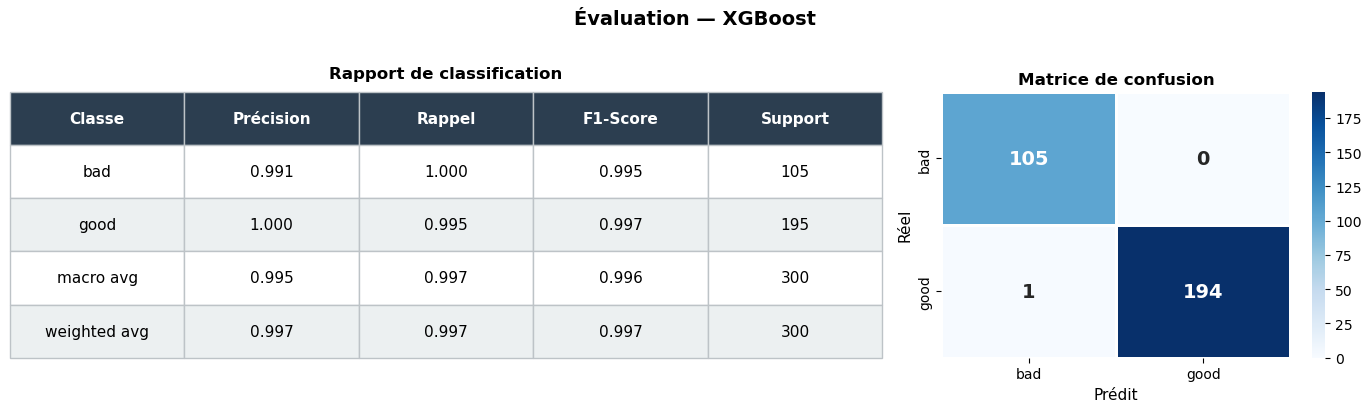

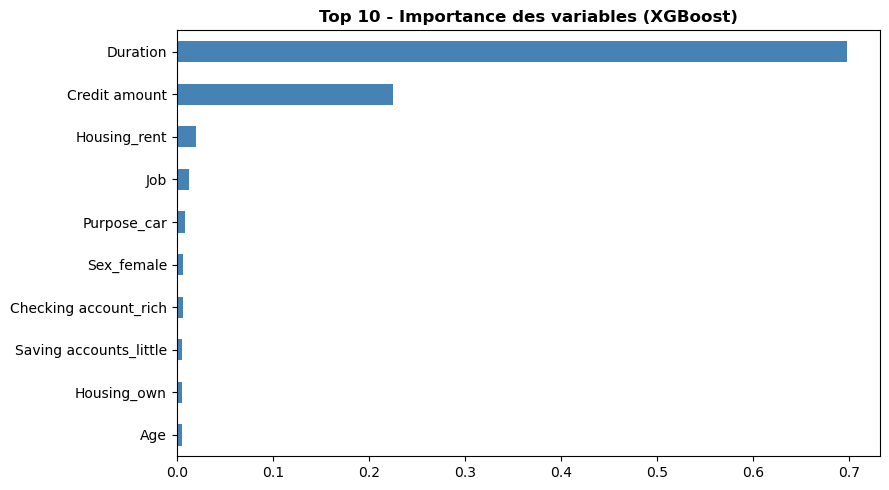

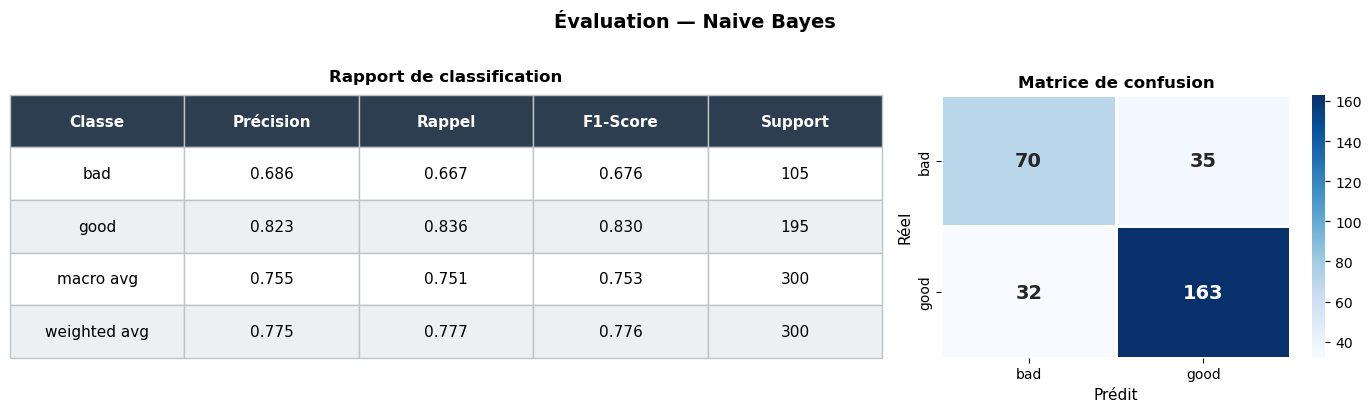

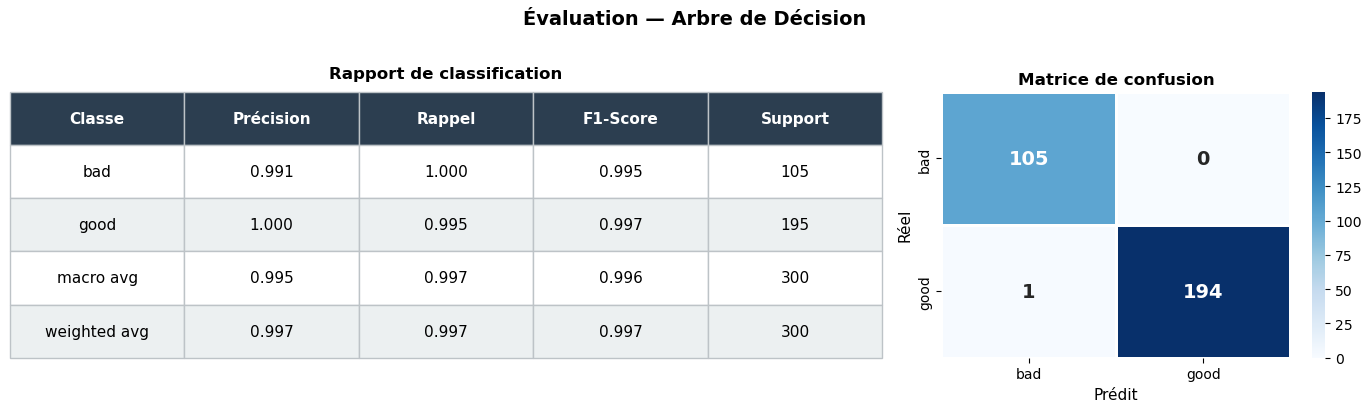

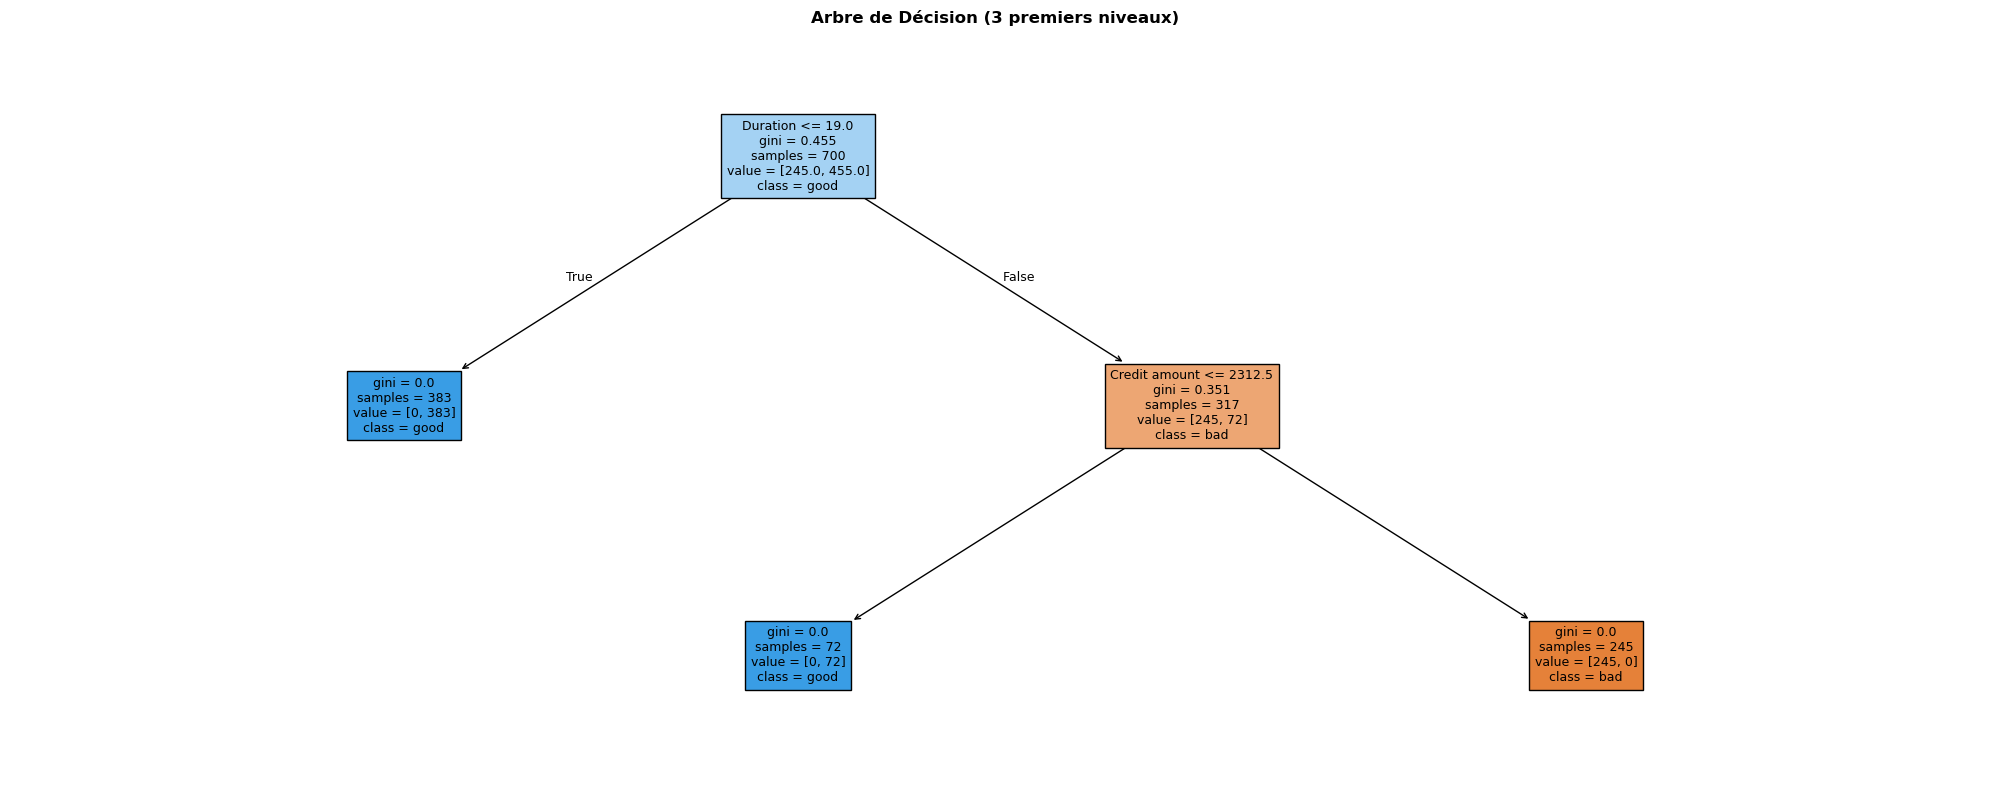

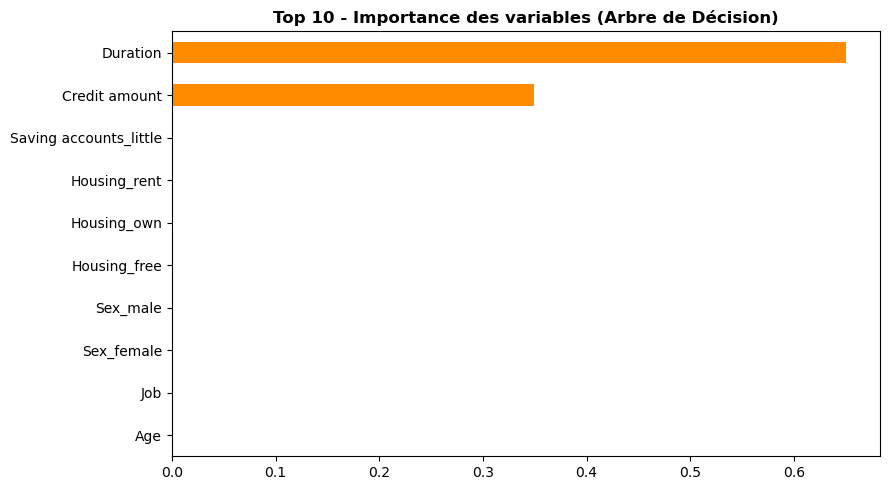

Meilleur K : 14


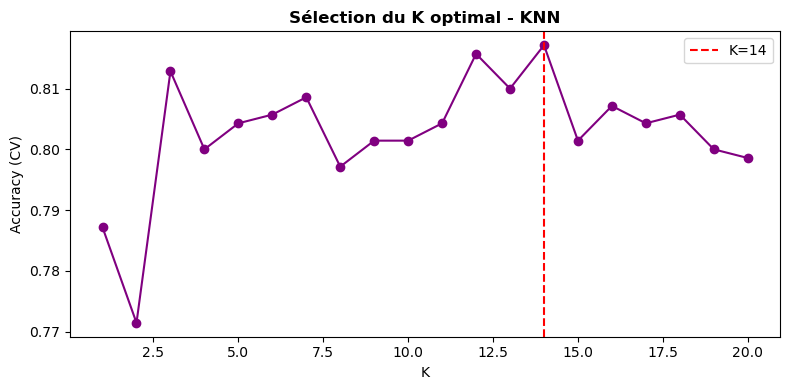

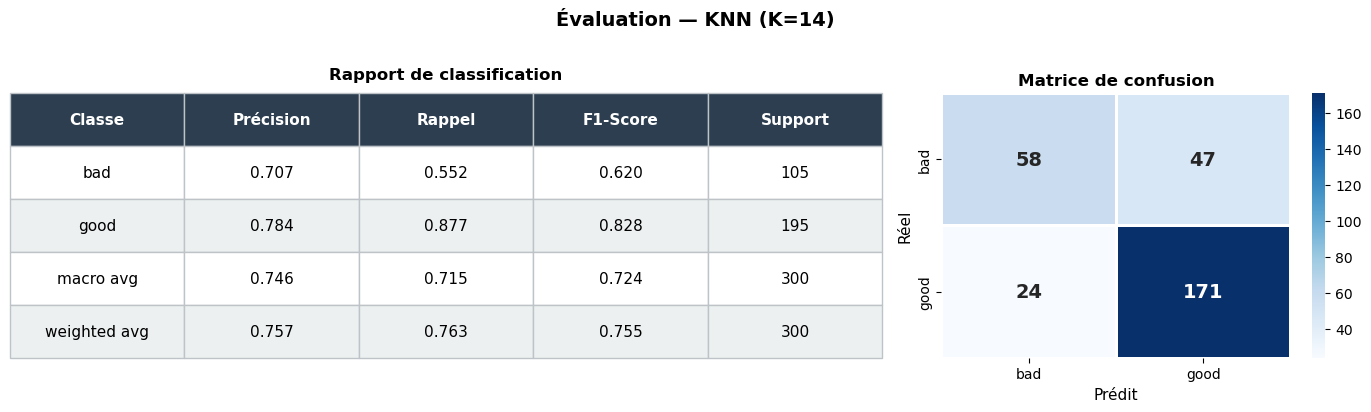

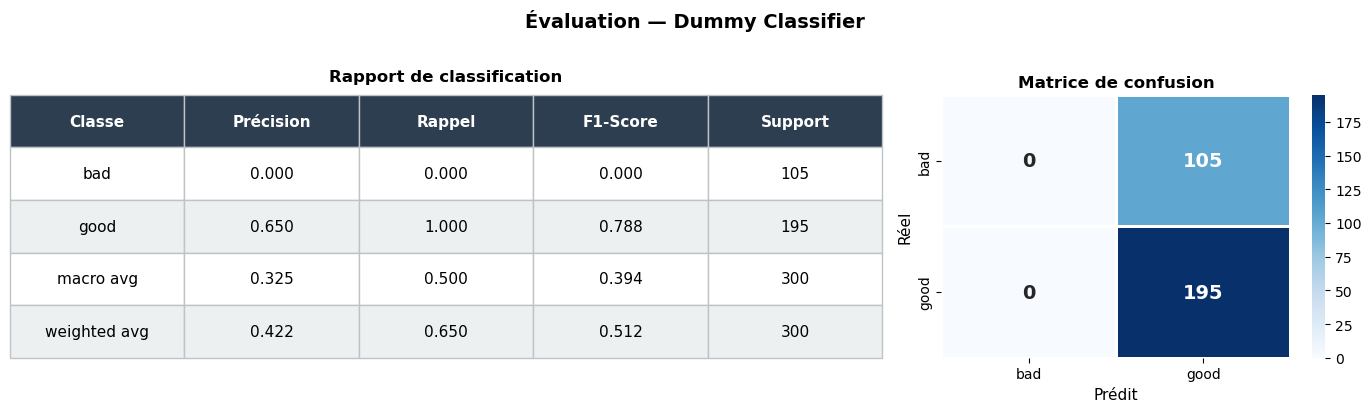

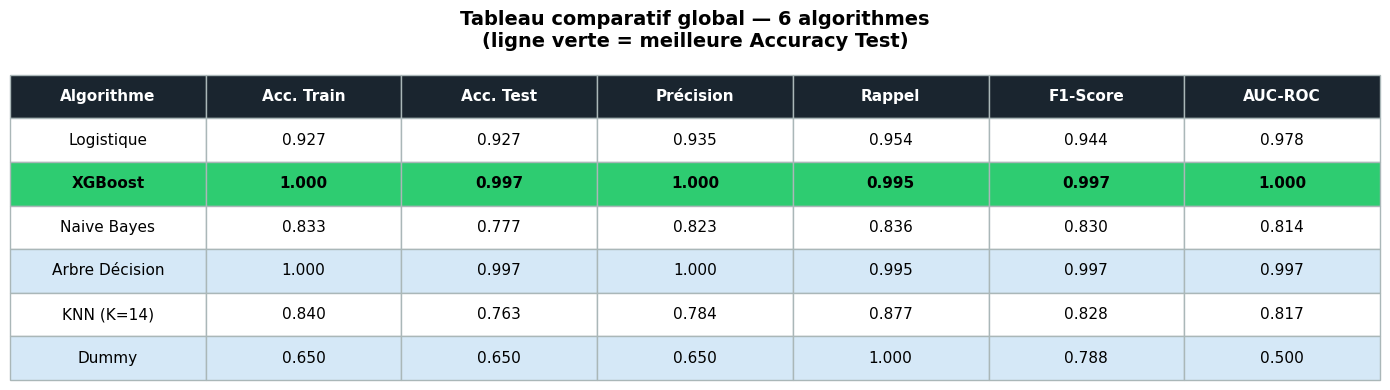

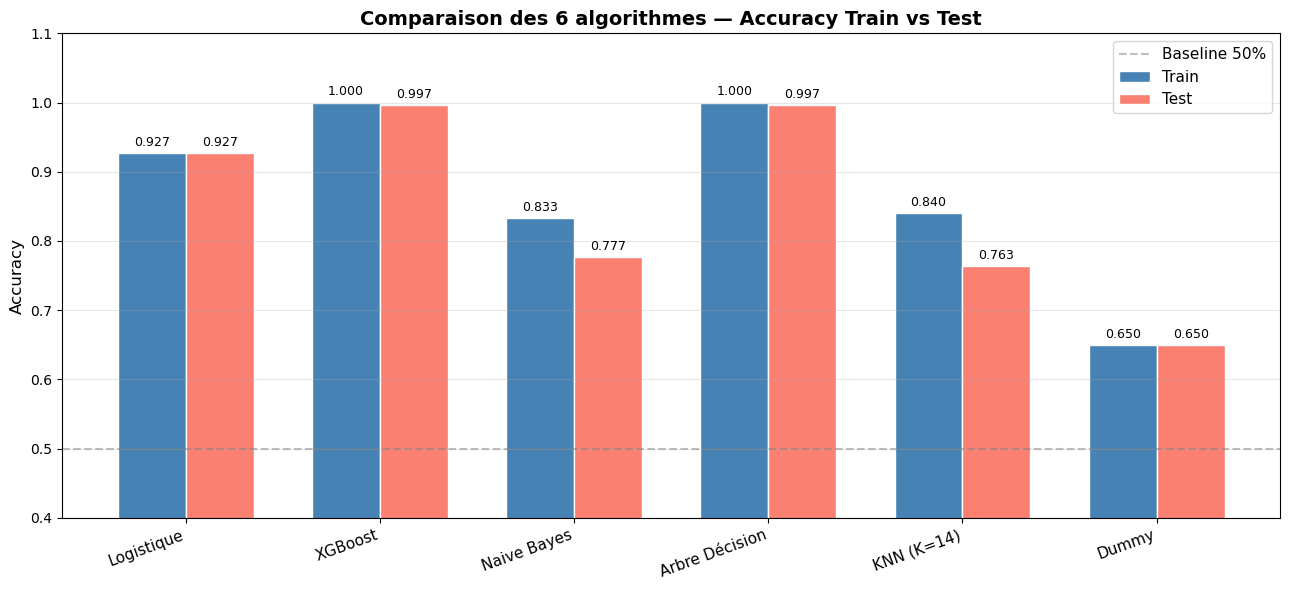


✅ Analyse terminée. Tous les graphiques et tableaux ont été sauvegardés.


In [4]:
##classification des algorithme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. CHARGEMENT DES DONNÉES (sans affichage des caractéristiques)
# ============================================================
dat = pd.read_csv("german_credit_data.csv", index_col=0)

# Création de la variable cible
med_amount   = dat["Credit amount"].median()
med_duration = dat["Duration"].median()
dat["Risk"] = np.where(
    (dat["Credit amount"] > med_amount) & (dat["Duration"] > med_duration),
    "bad", "good"
)

# Imputation des valeurs manquantes par le mode
for col in ["Saving accounts", "Checking account"]:
    dat[col].fillna(dat[col].mode()[0], inplace=True)

# ============================================================
# 2. ENCODAGE ONE-HOT
# ============================================================
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
dat_encoded = pd.get_dummies(dat, columns=cat_cols, drop_first=False)
dat_encoded["good"] = (dat_encoded["Risk"] == "good").astype(int)
dat_encoded.drop(columns=["Risk"], inplace=True)

# ============================================================
# 3. MATRICE DE CORRÉLATION (une seule figure claire)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 13))
corr = dat_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))          # triangle supérieur masqué
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.4, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": .75}, ax=ax)
ax.set_title("Matrice de corrélation complète (triangulaire)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("plot_correlation.png", dpi=120)
plt.show()

# ============================================================
# 4. SPLIT TRAIN / TEST (70/30 stratifié)
# ============================================================
X = dat_encoded.drop(columns=["good"])
y = dat_encoded["good"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalisation pour KNN et Naive Bayes
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)

# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def get_metrics(modele, Xtr, Xte, ytr, yte):
    """Retourne toutes les métriques d'évaluation."""
    y_pred_tr = modele.predict(Xtr)
    y_pred_te = modele.predict(Xte)

    # Probabilités pour AUC (si disponible)
    try:
        proba_te = modele.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, proba_te)
    except Exception:
        auc = np.nan

    return {
        "Accuracy Train" : accuracy_score(ytr, y_pred_tr),
        "Accuracy Test"  : accuracy_score(yte, y_pred_te),
        "Precision"      : precision_score(yte, y_pred_te, zero_division=0),
        "Recall"         : recall_score(yte, y_pred_te, zero_division=0),
        "F1-Score"       : f1_score(yte, y_pred_te, zero_division=0),
        "AUC-ROC"        : auc,
        "_y_pred"        : y_pred_te,
        "_cm"            : confusion_matrix(yte, y_pred_te),
        "_report"        : classification_report(yte, y_pred_te,
                               target_names=["bad", "good"], output_dict=True)
    }


def afficher_rapport_tableau(nom, metrics):
    """Affiche le rapport de classification sous forme de tableau matplotlib."""
    report = metrics["_report"]
    classes = ["bad", "good", "macro avg", "weighted avg"]

    rows = []
    for cls in classes:
        if cls in report:
            r = report[cls]
            rows.append([
                cls,
                f"{r.get('precision', 0):.3f}",
                f"{r.get('recall', 0):.3f}",
                f"{r.get('f1-score', 0):.3f}",
                f"{int(r.get('support', 0))}"
            ])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                             gridspec_kw={"width_ratios": [2, 1]})
    fig.suptitle(f"Évaluation — {nom}", fontsize=14, fontweight='bold', y=1.02)

    # --- Tableau rapport de classification ---
    ax1 = axes[0]
    ax1.axis('off')
    col_labels = ["Classe", "Précision", "Rappel", "F1-Score", "Support"]
    table = ax1.table(
        cellText   = rows,
        colLabels  = col_labels,
        cellLoc    = 'center',
        loc        = 'center',
        bbox       = [0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2c3e50")
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor("#ecf0f1")
        else:
            cell.set_facecolor("#ffffff")
        cell.set_edgecolor("#bdc3c7")
    ax1.set_title("Rapport de classification", fontsize=12, fontweight='bold', pad=10)

    # --- Matrice de confusion ---
    ax2 = axes[1]
    cm = metrics["_cm"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["bad", "good"],
                yticklabels=["bad", "good"],
                linewidths=1, ax=ax2,
                annot_kws={"size": 14, "weight": "bold"})
    ax2.set_xlabel("Prédit",  fontsize=11)
    ax2.set_ylabel("Réel",    fontsize=11)
    ax2.set_title("Matrice de confusion", fontsize=12, fontweight='bold')

    plt.tight_layout()
    fname = f"rapport_{nom.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()


# ============================================================
# 5. ENTRAÎNEMENT DES 6 MODÈLES
# ============================================================
resultats     = {}
all_metrics   = {}

# ---- 5.1 Régression Logistique ----
logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train, y_train)
m = get_metrics(logit, X_train, X_test, y_train, y_test)
all_metrics["Logistique"] = m
afficher_rapport_tableau("Régression Logistique", m)
resultats["Logistique"] = (m["Accuracy Train"], m["Accuracy Test"])

# ---- 5.2 XGBoost ----
xgb_model = xgb.XGBClassifier(
    eta=0.1, max_depth=5, gamma=0, n_estimators=15,
    subsample=0.8, colsample_bytree=0.8, seed=1,
    eval_metric="error", verbosity=0
)
xgb_model.fit(X_train, y_train)
m = get_metrics(xgb_model, X_train, X_test, y_train, y_test)
all_metrics["XGBoost"] = m
afficher_rapport_tableau("XGBoost", m)
resultats["XGBoost"] = (m["Accuracy Train"], m["Accuracy Test"])

# Importance des variables XGBoost
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(kind="barh", figsize=(9, 5), color="steelblue")
plt.title("Top 10 - Importance des variables (XGBoost)", fontweight='bold')
plt.tight_layout(); plt.savefig("plot_importance_xgb.png", dpi=100); plt.show()

# ---- 5.3 Naive Bayes ----
nb = GaussianNB()
nb.fit(Xtr_sc, y_train)
m = get_metrics(nb, Xtr_sc, Xte_sc, y_train, y_test)
all_metrics["Naive Bayes"] = m
afficher_rapport_tableau("Naive Bayes", m)
resultats["Naive Bayes"] = (m["Accuracy Train"], m["Accuracy Test"])

# ---- 5.4 Arbre de Décision ----
dtree = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dtree.fit(X_train, y_train)
m = get_metrics(dtree, X_train, X_test, y_train, y_test)
all_metrics["Arbre Décision"] = m
afficher_rapport_tableau("Arbre de Décision", m)
resultats["Arbre Décision"] = (m["Accuracy Train"], m["Accuracy Test"])

plt.figure(figsize=(20, 8))
plot_tree(dtree, feature_names=X.columns, class_names=["bad", "good"],
          filled=True, max_depth=3, fontsize=9)
plt.title("Arbre de Décision (3 premiers niveaux)", fontweight='bold')
plt.tight_layout(); plt.savefig("plot_tree.png", dpi=100); plt.show()

feat_imp_tree = pd.Series(dtree.feature_importances_, index=X.columns)
feat_imp_tree.nlargest(10).sort_values().plot(kind="barh", figsize=(9, 5), color="darkorange")
plt.title("Top 10 - Importance des variables (Arbre de Décision)", fontweight='bold')
plt.tight_layout(); plt.savefig("plot_importance_tree.png", dpi=100); plt.show()

# ---- 5.5 KNN ----
k_scores = []
k_range  = range(1, 21)
for k in k_range:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             Xtr_sc, y_train, cv=5, scoring="accuracy")
    k_scores.append(scores.mean())

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Meilleur K : {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker="o", color="purple")
plt.axvline(x=best_k, color="red", linestyle="--", label=f"K={best_k}")
plt.xlabel("K"); plt.ylabel("Accuracy (CV)")
plt.title("Sélection du K optimal - KNN", fontweight='bold'); plt.legend()
plt.tight_layout(); plt.savefig("plot_knn_k.png", dpi=100); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(Xtr_sc, y_train)
m = get_metrics(knn, Xtr_sc, Xte_sc, y_train, y_test)
all_metrics[f"KNN (K={best_k})"] = m
afficher_rapport_tableau(f"KNN (K={best_k})", m)
resultats[f"KNN (K={best_k})"] = (m["Accuracy Train"], m["Accuracy Test"])

# ---- 5.6 Dummy Classifier (baseline) ----
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
m = get_metrics(dummy, X_train, X_test, y_train, y_test)
all_metrics["Dummy"] = m
afficher_rapport_tableau("Dummy Classifier", m)
resultats["Dummy"] = (m["Accuracy Train"], m["Accuracy Test"])

# ============================================================
# 6. TABLEAU COMPARATIF GLOBAL (toutes métriques)
# ============================================================
rows_comp = []
for nom, m in all_metrics.items():
    rows_comp.append([
        nom,
        f"{m['Accuracy Train']:.3f}",
        f"{m['Accuracy Test']:.3f}",
        f"{m['Precision']:.3f}",
        f"{m['Recall']:.3f}",
        f"{m['F1-Score']:.3f}",
        f"{m['AUC-ROC']:.3f}" if not np.isnan(m['AUC-ROC']) else "N/A"
    ])

col_labels = ["Algorithme", "Acc. Train", "Acc. Test",
              "Précision", "Rappel", "F1-Score", "AUC-ROC"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText  = rows_comp,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Mise en forme : en-tête bleu foncé, lignes alternées
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1a252f")
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor("#d5e8f7")
    else:
        cell.set_facecolor("#ffffff")
    cell.set_edgecolor("#aab7b8")

# Mettre en vert la meilleure accuracy test
best_row = 1 + max(range(len(rows_comp)),
                   key=lambda i: float(rows_comp[i][2]))
for col in range(len(col_labels)):
    table[(best_row, col)].set_facecolor("#2ecc71")
    table[(best_row, col)].set_text_props(fontweight='bold')

ax.set_title("Tableau comparatif global — 6 algorithmes\n(ligne verte = meilleure Accuracy Test)",
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("tableau_comparatif.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# 7. GRAPHIQUE COMPARATIF BARRES (Train vs Test)
# ============================================================
noms         = list(resultats.keys())
train_scores = [v[0] for v in resultats.values()]
test_scores  = [v[1] for v in resultats.values()]

x = np.arange(len(noms))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, train_scores, w, label="Train", color="steelblue",  edgecolor='white')
bars2 = ax.bar(x + w/2, test_scores,  w, label="Test",  color="salmon",     edgecolor='white')
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Comparaison des 6 algorithmes — Accuracy Train vs Test",
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(noms, rotation=20, ha="right", fontsize=11)
ax.set_ylim(0.4, 1.10)
ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label="Baseline 50%")
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plot_comparaison.png", dpi=120)
plt.show()

print("\n✅ Analyse terminée. Tous les graphiques et tableaux ont été sauvegardés.")